## Radioactive Decay

### Decay Statistics

In [1]:
import numpy as np

distance = 2 # mm
isotope = "Cs 137"

# Define data sets
counts_10s = np.array([11, 11, 7, 13, 12, 19, 6, 12, 9, 11, 8, 6, 11, 8, 10, 8, 8, 4, 9, 5, 11, 14, 10, 16, 10]) # add your data here
counts_5s = np.array([2, 0, 3, 7, 5, 2, 1, 7, 7, 0, 4,3,4,8,9,6,4,7,4,5,5,5,4,5,7,6,5,2,7,5,5,11,7,4,2,7,7,1,2,5,11,3,6,8,4,2,6,4,6,6
]) # add your data here

##### Histograms

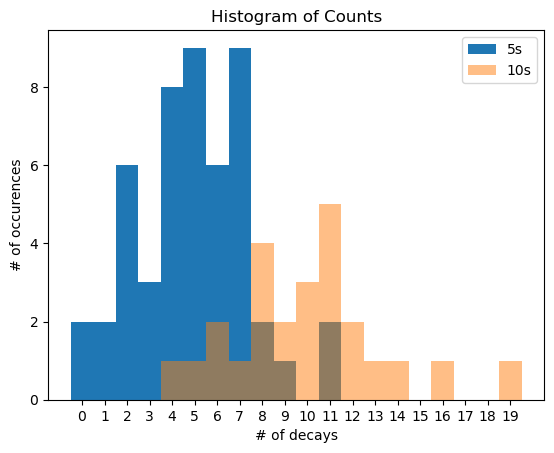

In [6]:
import matplotlib.pyplot as plt

# Determine the range of counts for the histogram
counts_max = int(max(max(counts_10s), max(counts_5s)))
counts_min = int(min(min(counts_10s), min(counts_5s)))
bins = range(counts_min, counts_max+2) # bins: [0, 1), [1, 2), ...

# Create the histogram
fig, ax = plt.subplots()
ax.set_xlabel('# of decays')
ax.set_ylabel('# of occurences')
ax.hist(counts_5s, bins=bins, align='left', label='5s')
ax.hist(counts_10s, bins=bins, align='left', label='10s', alpha=0.5)
ax.set_title('Histogram of Counts')
ax.set_xticks(range(counts_max+1))
ax.legend()
plt.show()


We can see a histogram of the counts of our two measurements. The x direction represents the amount of decays in the timeframe, and the y direction how many times that count occurred.

##### Normal distribution
Describe normal distribution here …

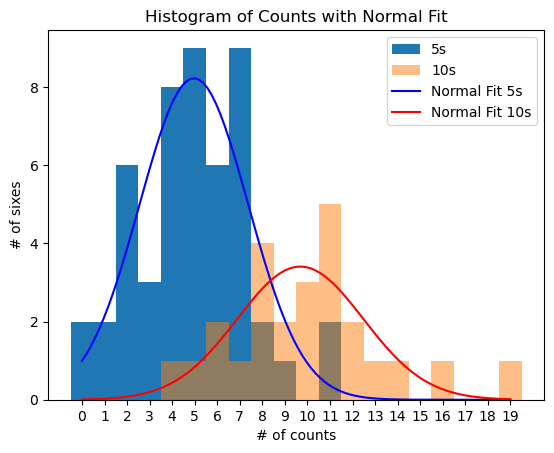

In [3]:
from scipy.optimize import curve_fit

# Define the normal distribution function
def normal_dist(x, A, mu, sigma):
    return A * (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Fit the normal distribution to the 10s data
x_10s = np.arange(counts_min, counts_max+1)
hist_10s, _ = np.histogram(counts_10s, bins=bins) # calculate the histogram for 10s data
# Use the histogram values as the y-data for fitting, add initial guesses for A, mu, sigma
popt_10s, _ = curve_fit(normal_dist, x_10s, hist_10s, 
                        p0=[np.max(hist_10s), np.mean(counts_10s), np.std(counts_10s)])

# Fit the normal distribution to the 5s data
x_5s = np.arange(counts_min, counts_max+1)
hist_5s, _ = np.histogram(counts_5s, bins=bins)
popt_5s, _ = curve_fit(normal_dist, x_5s, hist_5s, 
                       p0=[np.max(hist_5s), np.mean(counts_5s), np.std(counts_5s)])

# Plot the histograms and the fitted normal distributions
fig, ax = plt.subplots()
ax.set_xlabel('# of counts')
ax.set_ylabel('# of sixes')
ax.hist(counts_5s, bins=bins, align='left', label='5s')
ax.hist(counts_10s, bins=bins, align='left', label='10s', alpha=0.5)
x_fit = np.linspace(counts_min, counts_max, 100)
ax.plot(x_fit, normal_dist(x_fit, *popt_5s), 'b-', label='Normal Fit 5s')
ax.plot(x_fit, normal_dist(x_fit, *popt_10s), 'r-', label='Normal Fit 10s')
ax.set_title('Histogram of Counts with Normal Fit')
ax.set_xticks(range(counts_max+1))
ax.legend()

In [4]:
# Print the statistics and fit parameters
print(f"5s statistics: mean: {np.mean(counts_5s):.2f}, std: {np.std(counts_5s):.2f}")
print(f"5s fit parameters: µ={popt_5s[1]:.2f}, sigma={popt_5s[2]:.2f}")
print(f"10s statistics: mean: {np.mean(counts_10s):.2f}, std: {np.std(counts_10s):.2f}")
print(f"10s fit parameters: µ={popt_10s[1]:.2f}, sigma={popt_10s[2]:.2f}")

5s statistics: mean: 4.92, std: 2.46
5s fit parameters: µ=4.96, sigma=2.41
10s statistics: mean: 9.96, std: 3.32
10s fit parameters: µ=9.68, sigma=2.80


### Rolling Dice

##### Normal distribution
Describe binomial distribution here …

##### Histogram
Histogram for dice rolling experiment, including binomial distribution.

In [5]:
from scipy.special import comb

# Define the binomial distribution function
def binom(x, p, n):
    n_trials = 500
    # n = 24

    return n_trials * comb(n, x) * p**x * (1-p)**(n-x)

# data
counts = np.array([]) # add your data here
# alternatively generate array from csv file
# counts = np.genfromtxt('counts.csv', delimiter='c')

# calculate plot range and bins for histogram
counts_max = int(max(counts))
counts_min = int(min(counts))
bins = range(counts_min, counts_max+2) # bins: [0, 1), [1, 2), ...

# calculate the binomial distribution for the given parameters
x = np.linspace(counts_min, counts_max+1)
p = 1/6
n_dice = 24

binom_values = binom(x, p, n_dice)

fig, ax = plt.subplots()
ax.set_xlabel('# of counts')
ax.set_ylabel('# of sixes')
ax.hist(counts, bins=bins, align='left', label='Data')
ax.plot(x, binom_values, 'r-', label='Binomial Distribution')
ax.set_title('Histogram of Counts')
ax.set_xticks(range(counts_max+1))
plt.legend()
plt.show()


ValueError: max() iterable argument is empty

#### Curve fit

In [ ]:
# combine data of all lab teams
# counts_1 =
# counts_2 =
# counts_all = np.concatenate((counts_1, counts_2))

# calculate plot range and bins for histogram
counts_max = int(max(counts_all))
counts_min = int(min(counts_all))
bins = range(counts_min, counts_max+2) # bins: [0, 1), [1, 2), ...


hist, bin_edges = np.histogram(counts_all, bins)
coeff, pcov = curve_fit(binom, bin_edges[:-1], hist, p0=[p, n_dice])
p_fit, n_fit = coeff

binom_fit = binom(x, p_fit, n_fit)

# Plot the histogram and the fitted binomial distribution



In [ ]:
# compare the fit parameters to the expected values
